# Supervised Learning

## Classification

### Preparation

Untuk persiapan, kita akan memanggil seluruh library yang akan kita pakai pada project kali ini

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
%matplotlib inline

In [56]:
pwd

'/content'

In [57]:
train = pd.read_csv('Iris.csv')
train.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


### Exploratory Data Analysis

In [58]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [59]:
d = train.describe()
d

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


/tmp/ipykernel_1019/1811066998.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Species', data=train, palette='RdBu_r')


<Axes: xlabel='Species', ylabel='count'>

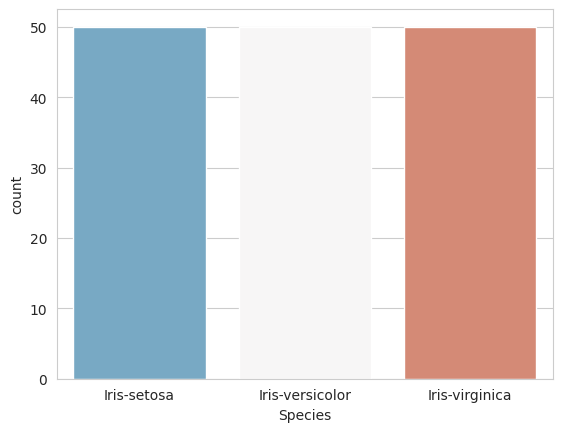

In [60]:
# Cek relative size dari survived dan not survived
sns.set_style('whitegrid')
sns.countplot(x='Species', data=train, palette='RdBu_r')
#sns.countplot(x='Survived',data=train,palette='RdBu_r')

/tmp/ipykernel_1019/3350202915.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Species', y='PetalLengthCm', data=train, palette='RdBu_r')


<Axes: xlabel='Species', ylabel='PetalLengthCm'>

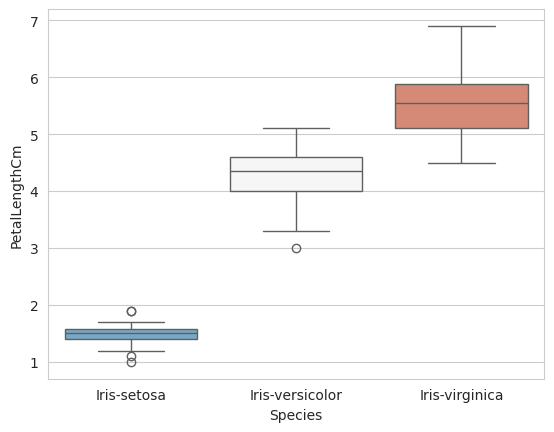

In [61]:
#Menunjukkan rata-rata dan sebaran ukuran panjang petal untuk masing-masing bunga
sns.set_style('whitegrid')
#sns.countplot(x='Survived',hue='Sex',data=train,palette='RdBu_r')
sns.boxplot(x='Species', y='PetalLengthCm', data=train, palette='RdBu_r')

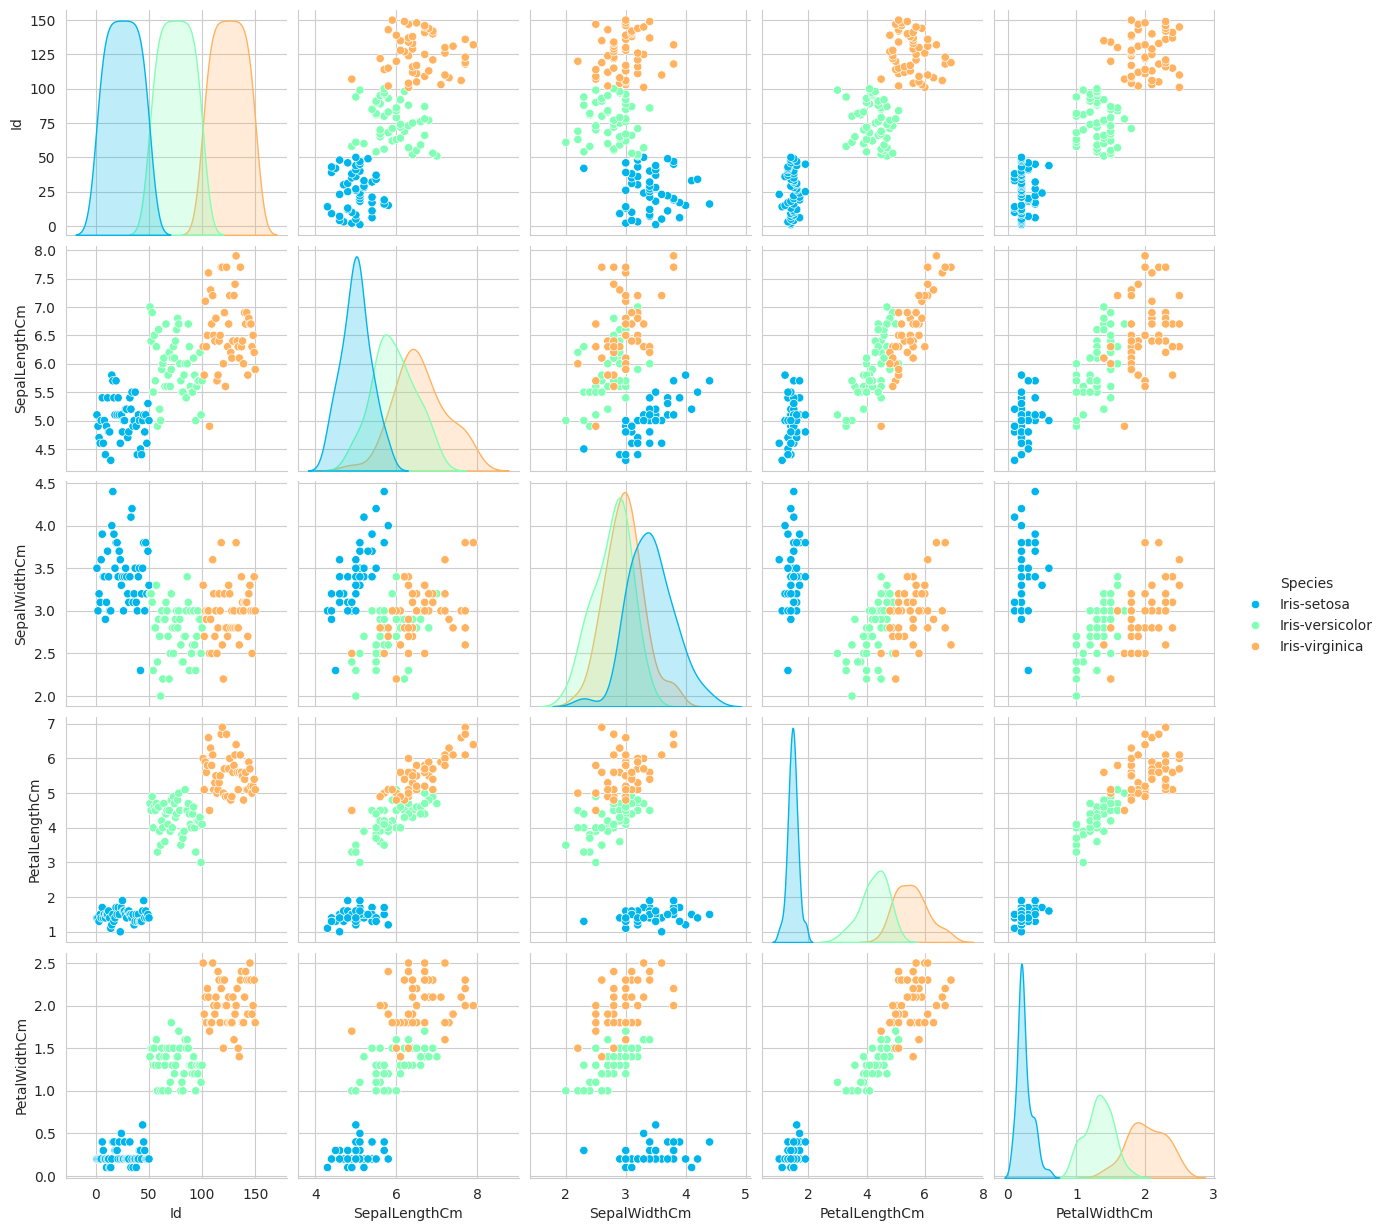

In [62]:
#Membandingkan semua kolom angka sekaligus, diwarnai berdasarkan Species
sns.set_style('whitegrid')
#sns.countplot(x='Survived',hue='Pclass',data=train,palette='rainbow')
sns.pairplot(train, hue='Species', palette='rainbow')

                 SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
Species                                                                  
Iris-setosa              5.006         3.418          1.464         0.244
Iris-versicolor          5.936         2.770          4.260         1.326
Iris-virginica           6.588         2.974          5.552         2.026


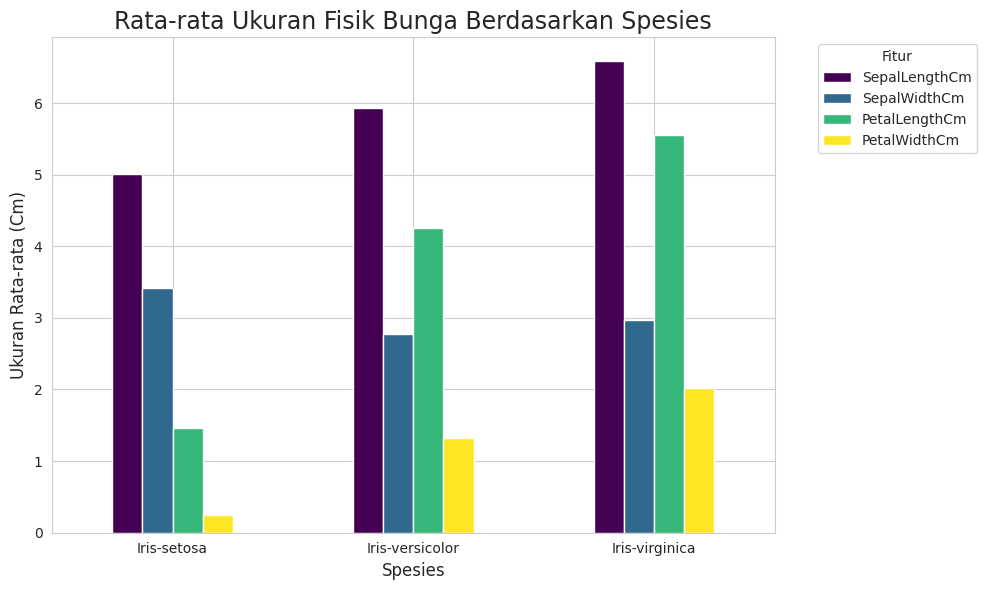

In [63]:
#f_class_survived=train.groupby('Pclass')['Survived'].mean()
#f_class_survived = pd.DataFrame(f_class_survived)
#f_class_survived
#f_class_survived.plot.bar(y='Survived')
#plt.title("Persentase penumpang yang selamat berdasarkan kelas",fontsize=17)

fitur_bunga = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
rata_rata_spesies = train.groupby('Species')[fitur_bunga].mean()
print(rata_rata_spesies)
rata_rata_spesies.plot.bar(figsize=(10, 6), colormap='viridis')
plt.title("Rata-rata Ukuran Fisik Bunga Berdasarkan Spesies", fontsize=17)
plt.xlabel("Spesies", fontsize=12)
plt.ylabel("Ukuran Rata-rata (Cm)", fontsize=12)
plt.xticks(rotation=0)
plt.legend(title="Fitur", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 6.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


<Axes: xlabel='Species', ylabel='PetalWidthCm'>

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 18.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


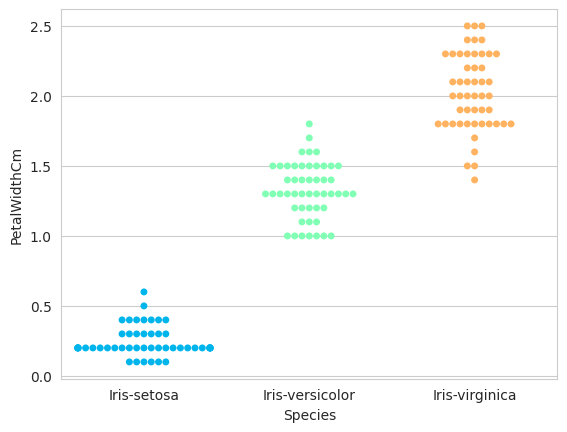

In [64]:
#Menunjukkan bahwa mayoritas ukuran kelopak bunga berada di angka desimal
sns.set_style('whitegrid')
#sns.countplot(x='Survived',hue='SibSp',data=train,palette='rainbow')
sns.swarmplot(x='Species', y='PetalWidthCm', data=train, palette='rainbow', hue='Species', legend=False)

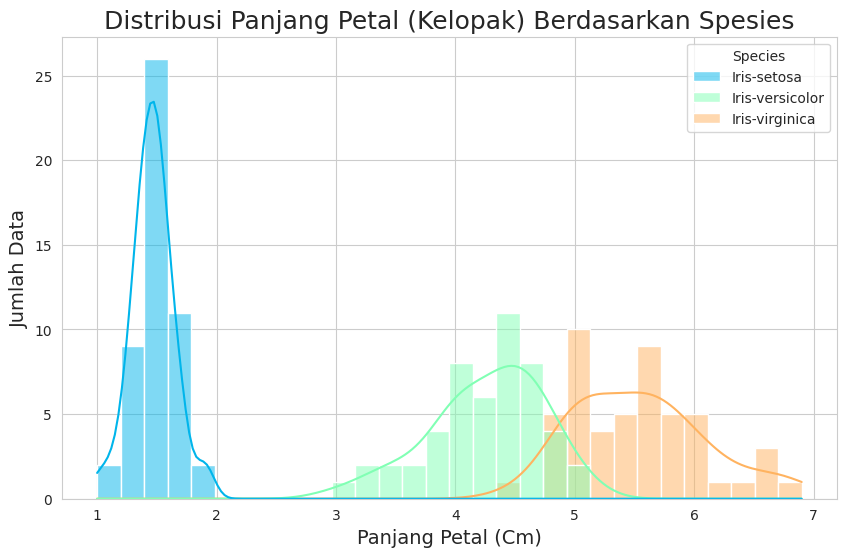

In [65]:
# Cek distribusi dari umur
#plt.xlabel("Usia penumpang",fontsize=18)
#plt.ylabel("Count",fontsize=18)
#plt.title("Histogram usia penumpang",fontsize=22)
#train['Age'].hist(bins=30,color='darkred',alpha=0.7,figsize=(10,6))

#Menggabungkan ukuran bunga Setosa, Versicolor, dan Virginica menjadi satu tumpukan grafik yang sama.
plt.figure(figsize=(10,6))
plt.title("Distribusi Panjang Petal (Kelopak) Berdasarkan Spesies", fontsize=18)
plt.xlabel("Panjang Petal (Cm)", fontsize=14)
plt.ylabel("Jumlah Data", fontsize=14)

# Gunakan histplot dari seaborn dengan hue='Species'
sns.histplot(data=train, x='PetalLengthCm', hue='Species', kde=True, palette='rainbow', bins=30)

plt.show()

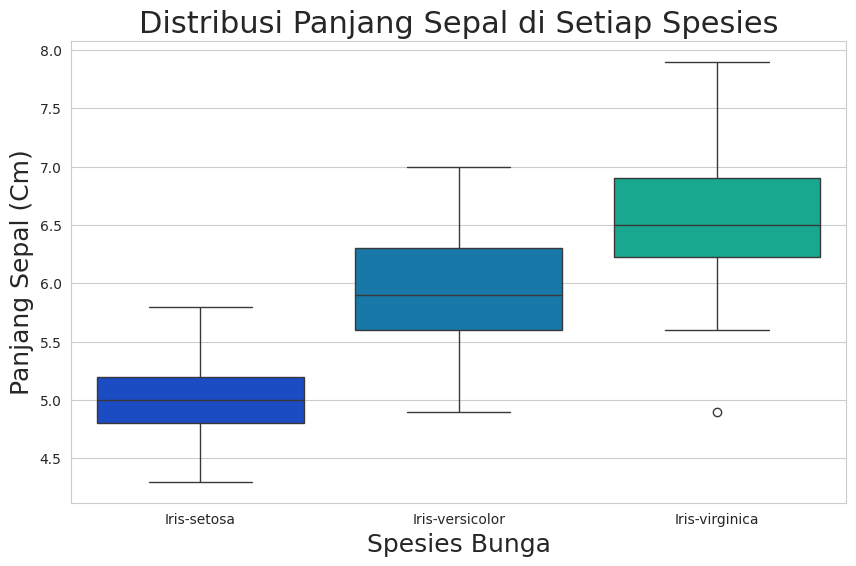

In [66]:
# Distribusi umur di setiap kelas
#plt.figure(figsize=(12, 10))
#plt.xlabel("Passenger Class",fontsize=18)
#plt.ylabel("Age",fontsize=18)
#sns.boxplot(x='Pclass',y='Age',data=train,palette='winter')

#
plt.figure(figsize=(10, 6))
plt.title("Distribusi Panjang Sepal di Setiap Spesies", fontsize=22)
plt.xlabel("Spesies Bunga", fontsize=18)
plt.ylabel("Panjang Sepal (Cm)", fontsize=18)

# Ganti Pclass menjadi Species, dan Age menjadi SepalLengthCm
sns.boxplot(x='Species', y='SepalLengthCm', data=train, palette='winter', hue='Species', legend=False)

plt.show()

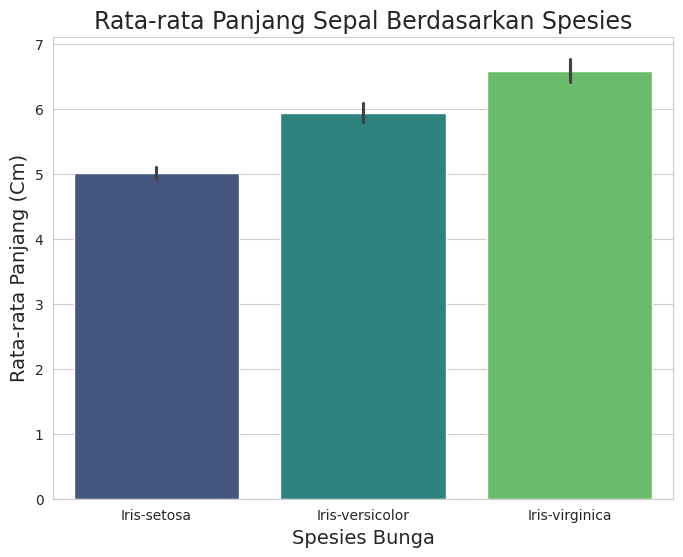

In [67]:
#f_class_Age=train.groupby('Pclass')['Age'].mean()
#f_class_Age = pd.DataFrame(f_class_Age)
#f_class_Age.plot.bar(y='Age')
#plt.title("Rata-rata usia penumpang berdasarkan kelas",fontsize=17)
#plt.ylabel("Age (years)", fontsize=17)
#plt.xlabel("Passenger class", fontsize=17)

plt.figure(figsize=(8, 6))

#Seaborn akan otomatis mencari rata-rata SepalLengthCm untuk tiap Spesies
sns.barplot(x='Species', y='SepalLengthCm', data=train, palette='viridis', hue='Species', legend=False)

# Kosmetik grafik
plt.title("Rata-rata Panjang Sepal Berdasarkan Spesies", fontsize=17)
plt.ylabel("Rata-rata Panjang (Cm)", fontsize=14)
plt.xlabel("Spesies Bunga", fontsize=14)
plt.show()

### Fitur Engineering

In [68]:

#a=list(f_class_Age['Age'])

#def impute_age(cols):
  #  Age = cols[0]
  #  Pclass = cols[1]

 #   if pd.isnull(Age):

   #     if Pclass == 1:
   #         return a[0]

   #     elif Pclass == 2:
    #        return a[1]
#
   #     else:
  #          return a[2]

  #  else:
    #    return Age

#Kalau di Titanic Feature Engineering-nya adalah mengisi data kosong
#di Iris Feature Engineering-nya adalah Feature Scaling (Standardisasi Ukuran).

from sklearn.preprocessing import StandardScaler
fitur_bunga = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
scaler = StandardScaler()

#Lakukan scalling
train[fitur_bunga] = scaler.fit_transform(train[fitur_bunga])

print("Data setelah dilakukan Feature Engineering (Scaling):")
print(train.head())

Data setelah dilakukan Feature Engineering (Scaling):
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1      -0.900681      1.032057      -1.341272     -1.312977  Iris-setosa
1   2      -1.143017     -0.124958      -1.341272     -1.312977  Iris-setosa
2   3      -1.385353      0.337848      -1.398138     -1.312977  Iris-setosa
3   4      -1.506521      0.106445      -1.284407     -1.312977  Iris-setosa
4   5      -1.021849      1.263460      -1.341272     -1.312977  Iris-setosa


In [69]:
#train['Age'] = train[['Age', 'Pclass']].apply(impute_age, axis=1)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
fitur_bunga = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
X = train[fitur_bunga]
le = LabelEncoder()
y_encoded = le.fit_transform(train['Species'])

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)
print("Bentuk matriks X awal:", X.shape)
print("Jumlah data untuk belajar AI (Train):", X_train.shape[0], "baris")
print("Jumlah data untuk ujian AI (Test):", X_test.shape[0], "baris")

Bentuk matriks X awal: (150, 4)
Jumlah data untuk belajar AI (Train): 120 baris
Jumlah data untuk ujian AI (Test): 30 baris


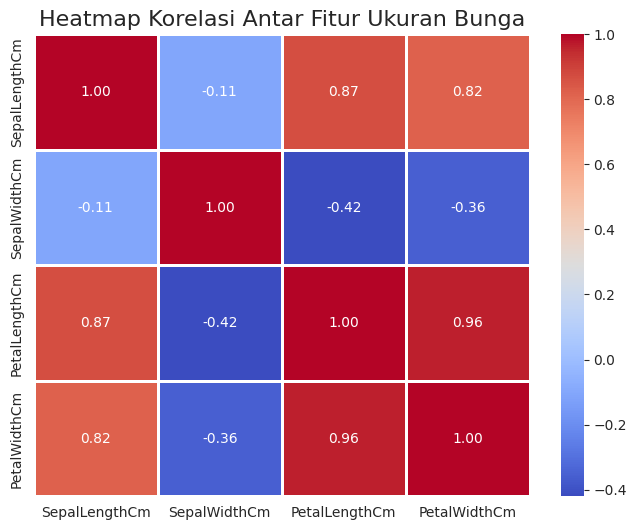

In [70]:
#d=train.describe()
#dT=d.T
#dT.plot.bar(y='count')
#plt.title("Bar plot jumlah fitur numerik",fontsize=17)

plt.figure(figsize=(8, 6))

#Membuat Heatmap dari korelasi antar fitur di variabel X
sns.heatmap(X.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=2)

plt.title("Heatmap Korelasi Antar Fitur Ukuran Bunga", fontsize=16)
plt.show()

In [71]:
# drop cabin karena memiliki banyak null value (>50%)
#train.drop('Cabin',axis=1,inplace=True)
#train.dropna(inplace=True)
#train.head()x`


#Jika di Titanic masalah utamanya adalah Data Kosong
#di dataset Iris masalah utamanya adalah Data Duplikat (Kembar).
jumlah_duplikat = train.duplicated().sum()
print("Jumlah data duplikat (kembar identik):", jumlah_duplikat)

if jumlah_duplikat > 0:
    train.drop_duplicates(inplace=True)
    print("Data duplikat berhasil dihapus!")
print("Total baris data sekarang:", train.shape[0])
train.head()

Jumlah data duplikat (kembar identik): 0
Total baris data sekarang: 150


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,-0.900681,1.032057,-1.341272,-1.312977,Iris-setosa
1,2,-1.143017,-0.124958,-1.341272,-1.312977,Iris-setosa
2,3,-1.385353,0.337848,-1.398138,-1.312977,Iris-setosa
3,4,-1.506521,0.106445,-1.284407,-1.312977,Iris-setosa
4,5,-1.021849,1.263460,-1.341272,-1.312977,Iris-setosa


In [72]:
# Drop semua kolom yang tidak penting
#train.drop(['PassengerId','Name','Ticket'],axis=1,inplace=True)
#train.head()

train.drop(['Id'], axis=1, inplace=True, errors='ignore')

#Tabel sekarang hanya berisi data yang 100% penting
print("Sisa kolom saat ini:", train.columns.tolist())
train.head()

Sisa kolom saat ini: ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,-0.900681,1.032057,-1.341272,-1.312977,Iris-setosa
1,-1.143017,-0.124958,-1.341272,-1.312977,Iris-setosa
2,-1.385353,0.337848,-1.398138,-1.312977,Iris-setosa
3,-1.506521,0.106445,-1.284407,-1.312977,Iris-setosa
4,-1.021849,1.263460,-1.341272,-1.312977,Iris-setosa


In [73]:
from sklearn.preprocessing import LabelEncoder

#le = LabelEncoder()
#train['Sex'] = le.fit_transform(train['Sex'])
#train['Embarked'] = le.fit_transform(train['Embarked'])
#train.head()

le = LabelEncoder()

#Ubah teks spesies menjadi angka matematis
train['Species'] = le.fit_transform(train['Species'])
print("Tabel data setelah Encoding:")
train.head()

Tabel data setelah Encoding:


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,-0.900681,1.032057,-1.341272,-1.312977,0
1,-1.143017,-0.124958,-1.341272,-1.312977,0
2,-1.385353,0.337848,-1.398138,-1.312977,0
3,-1.506521,0.106445,-1.284407,-1.312977,0
4,-1.021849,1.263460,-1.341272,-1.312977,0


### Training

In [74]:
from sklearn.model_selection import train_test_split
#X_train, X_test, y_train, y_test = train_test_split(train.drop('Survived',axis=1),
#                                                    train['Survived'], test_size=0.30,
#                                                    random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    train.drop('Species', axis=1), #X Ambil semua kecuali kolom Spesies
    train['Species'],
    test_size=0.30,
    random_state=42
)

In [75]:
#print(f'Train shape: {X_train.shape}')
#print(f'Test shape: {X_test.shape}')
print("Total data awal:", train.shape[0], "baris")
print("Jumlah data untuk belajar (X_train):", X_train.shape[0], "baris")
print("Jumlah data untuk ujian (X_test):", X_test.shape[0], "baris")

Total data awal: 150 baris
Jumlah data untuk belajar (X_train): 105 baris
Jumlah data untuk ujian (X_test): 45 baris


# **KNN**

In [76]:
from sklearn.neighbors import KNeighborsClassifier
clf1 = KNeighborsClassifier()

clf1.fit(X_train, y_train)

KNeighborsClassifier()

In [77]:
y_pred = clf1.predict(X_test)

### Evaluation

In [78]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred) #akurasi model
print(f'Akurasi Model KNN: {accuracy:.2f}')

print("Confusion Matrix:") #confusion matrix nya
print(confusion_matrix(y_test, y_pred))

print("Classification Report:") #laporan klasifikasi
print(classification_report(y_test, y_pred))

Akurasi Model KNN: 1.00
Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



### jika kita mau mengubah parameter apa saja yang akan kita gunakan maka bisa dilakukan seperti ini

In [79]:
clf2 = KNeighborsClassifier(n_neighbors=5, weights='distance', metric='euclidean')
clf2.fit(X_train, y_train)

y_pred1 = clf2.predict(X_test)

In [80]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred1) #akurasi model
print(f'Akurasi Model KNN: {accuracy:.2f}')

print("Confusion Matrix:") #confusion matrix nya
print(confusion_matrix(y_test, y_pred1))

print("Classification Report:") #laporan klasifikasi
print(classification_report(y_test, y_pred1))

Akurasi Model KNN: 1.00
Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



### jika ingin mencoba semua parameter

In [81]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import pandas as pd

# 1. Definisikan metrik-metrik scoring yang ingin digunakan
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, average='macro'),
    'recall': make_scorer(recall_score, average='macro'),
    'f1': make_scorer(f1_score, average='macro')
}

# 2. Parameter grid
param_grid = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# 3. Buat model KNN
knn = KNeighborsClassifier()

# 4. GridSearch dengan semua metrik, pilih 'f1' sebagai metrik utama (refit)
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring=scoring, refit='f1', verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

# 5. Hasil Cross-Validation (Training)
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_metrics = cv_results[['params', 'mean_test_accuracy', 'mean_test_precision', 'mean_test_recall', 'mean_test_f1']]
print("\n=== Hasil Evaluasi Training (Cross-Validation) ===")
print(cv_metrics.sort_values(by='mean_test_f1', ascending=False))

Fitting 5 folds for each of 12 candidates, totalling 60 fits

=== Hasil Evaluasi Training (Cross-Validation) ===
                                               params  mean_test_accuracy  \
0   {'metric': 'euclidean', 'n_neighbors': 3, 'wei...            0.942857   
1   {'metric': 'euclidean', 'n_neighbors': 3, 'wei...            0.942857   
3   {'metric': 'euclidean', 'n_neighbors': 5, 'wei...            0.942857   
10  {'metric': 'manhattan', 'n_neighbors': 7, 'wei...            0.942857   
11  {'metric': 'manhattan', 'n_neighbors': 7, 'wei...            0.933333   
9   {'metric': 'manhattan', 'n_neighbors': 5, 'wei...            0.933333   
5   {'metric': 'euclidean', 'n_neighbors': 7, 'wei...            0.933333   
7   {'metric': 'manhattan', 'n_neighbors': 3, 'wei...            0.923810   
8   {'metric': 'manhattan', 'n_neighbors': 5, 'wei...            0.923810   
4   {'metric': 'euclidean', 'n_neighbors': 7, 'wei...            0.923810   
6   {'metric': 'manhattan', 'n_neighbors

In [82]:
# Simpan hasil evaluasi ke file Excel
cv_metrics_sorted = cv_metrics.sort_values(by='mean_test_f1', ascending=False)
cv_metrics_sorted.to_excel("hasil_gridsearch_knn.xlsx", index=False)

print("Hasil telah disimpan ke 'hasil_gridsearch_knn.xlsx'")


Hasil telah disimpan ke 'hasil_gridsearch_knn.xlsx'


In [83]:
best_model = grid_search.best_estimator_
print("\n=== Parameter Terbaik ===")
print(grid_search.best_params_)


=== Parameter Terbaik ===
{'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}


In [84]:
y_pred = best_model.predict(X_test)
print("\n=== Evaluasi di Test Set ===")
print(f"Akurasi:  {accuracy_score(y_test, y_pred):.2f}")
print(f"Presisi:  {precision_score(y_test, y_pred, average='macro'):.2f}")
print(f"Recall:   {recall_score(y_test, y_pred, average='macro'):.2f}")
print(f"F1-Score: {f1_score(y_test, y_pred, average='macro'):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


=== Evaluasi di Test Set ===
Akurasi:  1.00
Presisi:  1.00
Recall:   1.00
F1-Score: 1.00

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45

Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


In [85]:
import numpy as np


# Urutan [SepalLengthCm, SepalWidthCm, PetalLengthCm, PetalWidthCm]
# Contoh ini saya isi dengan ukuran yang secara biologis mirip bunga Virginica
data_bunga_baru = np.array([[6.5, 3.0, 5.5, 2.0]])
# data_bunga_baru = scaler.transform(data_bunga_baru)
prediksi_angka = best_model.predict(data_bunga_baru)

#Kembalikan angka (0/1/2) menjadi teks huruf (Iris-setosa/versicolor/virginica)
nama_spesies = le.inverse_transform(prediksi_angka)

print("Ukuran Input :", data_bunga_baru[0])
print("Sandi Angka  :", prediksi_angka[0])
print("Spesies      :", nama_spesies[0])

Ukuran Input : [6.5 3.  5.5 2. ]
Sandi Angka  : 2
Spesies      : Iris-virginica


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
